# FIRAS limits on monochromatic photon injection and dark photon mixing

This tutorial reproduces a few representative points from two FIRAS constraint figures in the paper:

- **Fig. 7** — FIRAS upper limit on monochromatic photon injection $\Delta N_\gamma/N_\gamma$ vs injection frequency $x_i$, at fixed redshift $z_h$ (Chluba 2015).
- **Fig. 8** — FIRAS upper limit on dark-photon kinetic mixing $\epsilon$ vs mass $m_{A'}$, via the resonant $\gamma\!\to\!A'$ depletion of the CMB blackbody (Chluba, Cyr & Johnson 2024).

Both follow the same recipe: run the PDE solver with the relevant injection scenario, build a per-unit-amplitude template $\Delta n(x)$, fit it against the FIRAS residuals, and invert. The paper figures sweep many points; here we run **3 points each** to demonstrate the workflow.

| Limit | CL | Source |
|---|---|---|
| $\|\mu\|<4.5\times10^{-5}$, $\|y\|<7.5\times10^{-6}$ | 68% | Fixsen+ 1996 |
| $\|\mu\|<9\times10^{-5}$, $\|y\|<1.5\times10^{-5}$ | 95% | Fixsen+ 1996 |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from spectroxide import (
    run_photon_sweep, solve,
    mu_from_photon_injection, greens_function_photon,
    g_bb, mu_shape, y_shape, ALPHA_RHO,
    FIRASData, MU_FIRAS_68, Y_FIRAS_68, MU_FIRAS_95,
    apply_style, C,
)
from spectroxide.dark_photon import resonance_redshift, gc_per_epsilon_sq

apply_style()
firas = FIRASData()
print(firas)

## 1. FIRAS limit on monochromatic photon injection

Inject $\Delta N_\gamma$ photons into a narrow line at $x_i = h\nu_i/(kT_z)$ at redshift $z_h$. The PDE returns $(\mu, y)$ that scale linearly with the injected $\Delta N_\gamma/N_\gamma$. Inverting the FIRAS bound at 68% CL,

$$\left.\frac{\Delta N_\gamma}{N_\gamma}\right|_{\max} = \min\!\left(\frac{|\mu|_{\rm FIRAS}}{|\mu_{\rm per\,unit}|},\ \frac{|y|_{\rm FIRAS}}{|y_{\rm per\,unit}|}\right).$$

The $\mu$ response vanishes at $x_0 = 4/(3\alpha_\rho)\approx 3.6$ (Chluba 2015) — energy- and number-injection cancel — so the limit is weakest there. We pick three illustrative points: a low-$x_i$ point at $z_h=2\times10^6$ where the bound is tight, an intermediate point near the $\mu$-zero, and a high-$x_i$ point at $z_h=3\times10^5$.

In [ ]:
def photon_limit_pde(x_inj, z_h, dn_over_n=1e-5):
    """Run PDE for monochromatic photon injection; return FIRAS 68% CL limit on Δ_N/N."""
    res = run_photon_sweep(
        x_inj=x_inj,
        delta_n_over_n=dn_over_n,
        sigma_x=0.05 * x_inj,
        z_injections=[z_h],
        z_end=500,
        timeout=900,
    )['results'][0]
    mu_per = res['pde_mu'] / dn_over_n
    y_per  = res['pde_y']  / dn_over_n
    lim_mu = MU_FIRAS_68 / abs(mu_per) if abs(mu_per) > 1e-20 else np.inf
    lim_y  = Y_FIRAS_68  / abs(y_per)  if abs(y_per)  > 1e-20 else np.inf
    return min(lim_mu, lim_y), mu_per, y_per


points = [
    (1.0, 2e6, C['blue']),
    (3.0, 1e6, C['orange']),  # near μ-zero
    (8.0, 3e5, C['teal']),
]

print(f'{"x_i":>5s} {"z_h":>10s}  {"μ/unit":>10s}  {"y/unit":>10s}  {"ΔN/N max":>10s}')
print('-' * 55)
pde_results = []
for x_i, z_h, _ in points:
    lim, mu_per, y_per = photon_limit_pde(x_i, z_h)
    pde_results.append(lim)
    print(f'{x_i:5.1f} {z_h:10.0e}  {mu_per:+10.2e}  {y_per:+10.2e}  {lim:10.2e}')

# Build GF curves at the three z_h for context
x_grid = np.logspace(np.log10(0.1), np.log10(15), 200)

def y_per_unit_gf(x_i, z_h):
    """Project the photon GF onto the y-shape via simple least-squares."""
    xg = np.linspace(0.5, 25, 1000)
    dn = greens_function_photon(xg, x_i, z_h)
    A = np.column_stack([mu_shape(xg), y_shape(xg), g_bb(xg)])
    coef, *_ = np.linalg.lstsq(A, dn, rcond=None)
    return coef[1]

/tmp/ipykernel_28588/3872152923.py:7: RuntimeWarning: divide by zero encountered in divide
  np.where(np.abs(y_g)  > 1e-20, Y_FIRAS_68  / np.abs(y_g),  np.inf),


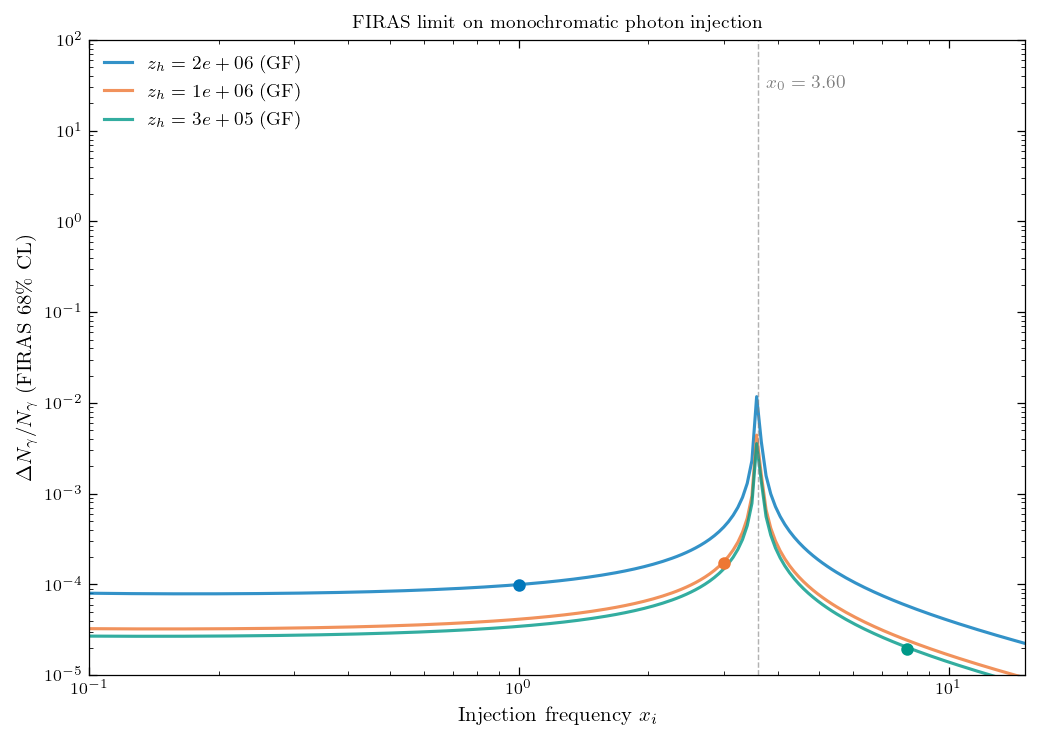

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
for (x_i, z_h, color), lim in zip(points, pde_results):
    mu_g = np.array([mu_from_photon_injection(x, z_h, 1.0) for x in x_grid])
    y_g  = np.array([y_per_unit_gf(x, z_h) for x in x_grid])
    lim_g = np.minimum(
        np.where(np.abs(mu_g) > 1e-20, MU_FIRAS_68 / np.abs(mu_g), np.inf),
        np.where(np.abs(y_g)  > 1e-20, Y_FIRAS_68  / np.abs(y_g),  np.inf),
    )
    ax.semilogy(x_grid, lim_g, color=color, lw=1.5, alpha=0.8,
                label=rf'$z_h={z_h:.0e}$ (GF)')
    ax.plot(x_i, lim, 'o', color=color, ms=5, mew=1, zorder=5)

x0 = 4.0 / (3.0 * ALPHA_RHO)
ax.axvline(x0, color='gray', ls='--', lw=0.7, alpha=0.6)
ax.text(x0 + 0.15, 3e1, rf'$x_0 = {x0:.2f}$', color='gray', fontsize=9)
ax.set(xlabel=r'Injection frequency $x_i$',
       ylabel=r'$\Delta N_\gamma / N_\gamma$ (FIRAS 68\% CL)',
       xscale='log', xlim=(0.1, 15), ylim=(1e-5, 1e2),
       title='FIRAS limit on monochromatic photon injection')
ax.legend(loc='upper left', fontsize=9)
ax.plot([], [], 'o', color='k', ms=4, mec='k', label='PDE')
plt.tight_layout(); plt.show()

## 2. FIRAS limit on dark-photon kinetic mixing

Resonant $\gamma\!\to\!A'$ conversion at $z_{\rm res}$, where $\omega_{\rm pl}(z_{\rm res})=m_{A'}$, depletes the CMB blackbody by

$$\Delta n(x,z_{\rm res}) = -[1 - e^{-\gamma_{\rm con}/x}]\,n_{\rm pl}(x), \qquad \gamma_{\rm con}=\frac{\pi\,\epsilon^2 m^2}{|d\ln\omega_{\rm pl}^2/d\ln a|\,T_\gamma\,H}\bigg|_{z_{\rm res}}$$

(narrow-width approximation, Mirizzi+2009; Chluba & Cyr 2024). Subsequent Comptonization and DC/BR partial rethermalization shape the surviving distortion.

**Pipeline.** For each mass: (i) find $z_{\rm res}$ from the plasma frequency; (ii) compute $\gamma_{\rm con}/\epsilon^2$; (iii) run the PDE with `dark_photon_resonance` injection at a reference $\epsilon$; (iv) build a per-$\gamma_{\rm con}$ template $\Delta n(x)$ and fit it to FIRAS via `firas.profile_limit_floating_T`; (v) translate the bound on $\gamma_{\rm con}$ back to $\epsilon$ via $\epsilon = \sqrt{\gamma_{\rm con}^{(95)}/(\gamma_{\rm con}/\epsilon^2)}$.



In [ ]:
def strip_gbb_nc(x, dn):
    """Number-conserving G_bb subtraction: enforces ∫ x² Δn dx = 0."""
    gbb = g_bb(x)
    alpha = np.trapz(x**2 * dn, x) / np.trapz(x**2 * gbb, x)
    return dn - alpha * gbb


def dark_photon_limit(m_ev, eps_ref=1e-8):
    """Self-consistent FIRAS 95% CL on ε at mass m. One-pass linear NWA template."""
    z_res = resonance_redshift(m_ev)
    gpe2, _ = gc_per_epsilon_sq(m_ev)
    gc_ref = gpe2 * eps_ref**2

    # PDE: solver auto-sets z_start=z_res and enables NC for depletion
    npts = 4000 if z_res < 1e6 else 8000
    res = solve(
        injection={'type': 'dark_photon_resonance', 'epsilon': eps_ref, 'm_ev': m_ev},
        z_end=100, n_points=npts, timeout=1500,
    )
    x_pde = res.x
    dn_per_gc = strip_gbb_nc(x_pde, res.delta_n) / gc_ref

    # FIRAS profile-likelihood limit on γ_con (floating T and galactic emission)
    gc_95 = firas.profile_limit_floating_T(
        lambda x: np.interp(x, x_pde, dn_per_gc), cl=0.95,
    )['upper_limit']
    eps_lim = np.sqrt(gc_95 / gpe2)

    # If the limit is far from the linearization point, iterate once
    if eps_lim / eps_ref > 3 or eps_ref / eps_lim > 3:
        return dark_photon_limit(m_ev, eps_ref=eps_lim)
    return z_res, eps_lim, gc_95


masses = [4e-10, 1e-9, 1e-8]  # post-recomb, bump, μ-era asymptote
print(f'{"m [eV]":>9s}  {"z_res":>7s}  {"γ_con^(95)":>12s}  {"ε_95":>10s}')
print('-' * 50)
dp_results = []
for m in masses:
    z_res, eps, gc = dark_photon_limit(m)
    dp_results.append((m, z_res, eps))
    print(f'{m:9.1e}  {z_res:7.0f}  {gc:12.2e}  {eps:10.2e}')

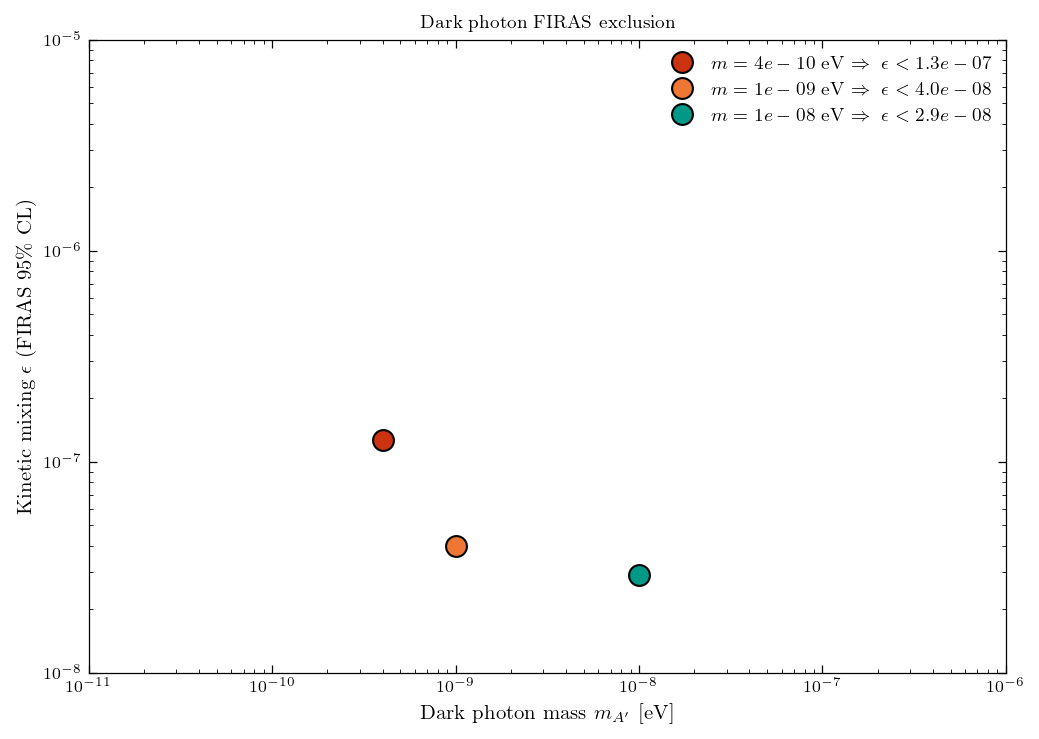

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

for (m, z_res, eps), color in zip(dp_results, [C['red'], C['orange'], C['teal']]):
    ax.plot(m, eps, 'o', color=color, ms=10, mec='k', mew=1, zorder=5,
            label=rf'$m={m:.0e}$ eV  $\Rightarrow\ \epsilon<{eps:.1e}$')

ax.set(xlabel=r"Dark photon mass $m_{A'}$ [eV]",
       ylabel=r'Kinetic mixing $\epsilon$ (FIRAS $95\%$ CL)',
       xlim=(1e-11, 1e-6), ylim=(1e-8, 1e-5), xscale="log", yscale="log",
       title='Dark photon FIRAS exclusion')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()